In [2]:
import requests
import pandas as pd
import io

# URLs for the adult.data and adult.names files
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
names_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names"

# 1. Download adult.names to get the column headers
try:
    names_response = requests.get(names_url)
    names_response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    names_content = names_response.text

    # Parse the names_content to extract column names
    # The .names file has a specific format; we need to parse it carefully.
    # We'll hardcode the column names for simplicity as parsing this file
    # precisely can be a bit intricate due to its structure.
    # The common column names for the Adult dataset are:
    column_names = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
    ]

    print("Successfully retrieved column names from adult.names.")

except requests.exceptions.RequestException as e:
    print(f"Error downloading adult.names: {e}")
    # Fallback if download fails: use known column names
    column_names = [
        'age', 'workclass', 'fnlwgt', 'education', 'education-num',
        'marital-status', 'occupation', 'relationship', 'race', 'sex',
        'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
    ]
    print("Using hardcoded column names due to download issue or for simplicity.")


# 2. Download adult.data and load it into a Pandas DataFrame
try:
    data_response = requests.get(data_url)
    data_response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Use io.StringIO to treat the string content as a file
    # na_values='?' is crucial here as missing values are encoded as '?' in this dataset
    # skipinitialspace=True helps handle potential leading spaces after commas
    df_adult = pd.read_csv(io.StringIO(data_response.text),
                           names=column_names,
                           na_values='?',
                           skipinitialspace=True)

    print("\nSuccessfully loaded adult.data into a Pandas DataFrame.")
    print("DataFrame Head:")
    print(df_adult.head())

    print("\nDataFrame Info (check for missing values):")
    df_adult.info()

    print("\nValue counts for '?' (now NaN) in 'workclass' and 'occupation':")
    print(df_adult['workclass'].value_counts(dropna=False))
    print(df_adult['occupation'].value_counts(dropna=False))

except requests.exceptions.RequestException as e:
    print(f"Error downloading adult.data: {e}")
    df_adult = None # Set DataFrame to None if download fails

Successfully retrieved column names from adult.names.

Successfully loaded adult.data into a Pandas DataFrame.
DataFrame Head:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-co

In [3]:
df_adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


<Axes: >

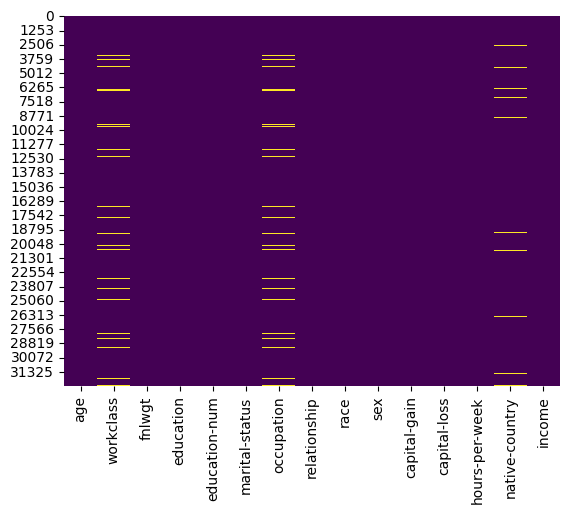

In [4]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.heatmap(df_adult.isnull(), cbar=False, cmap='viridis')

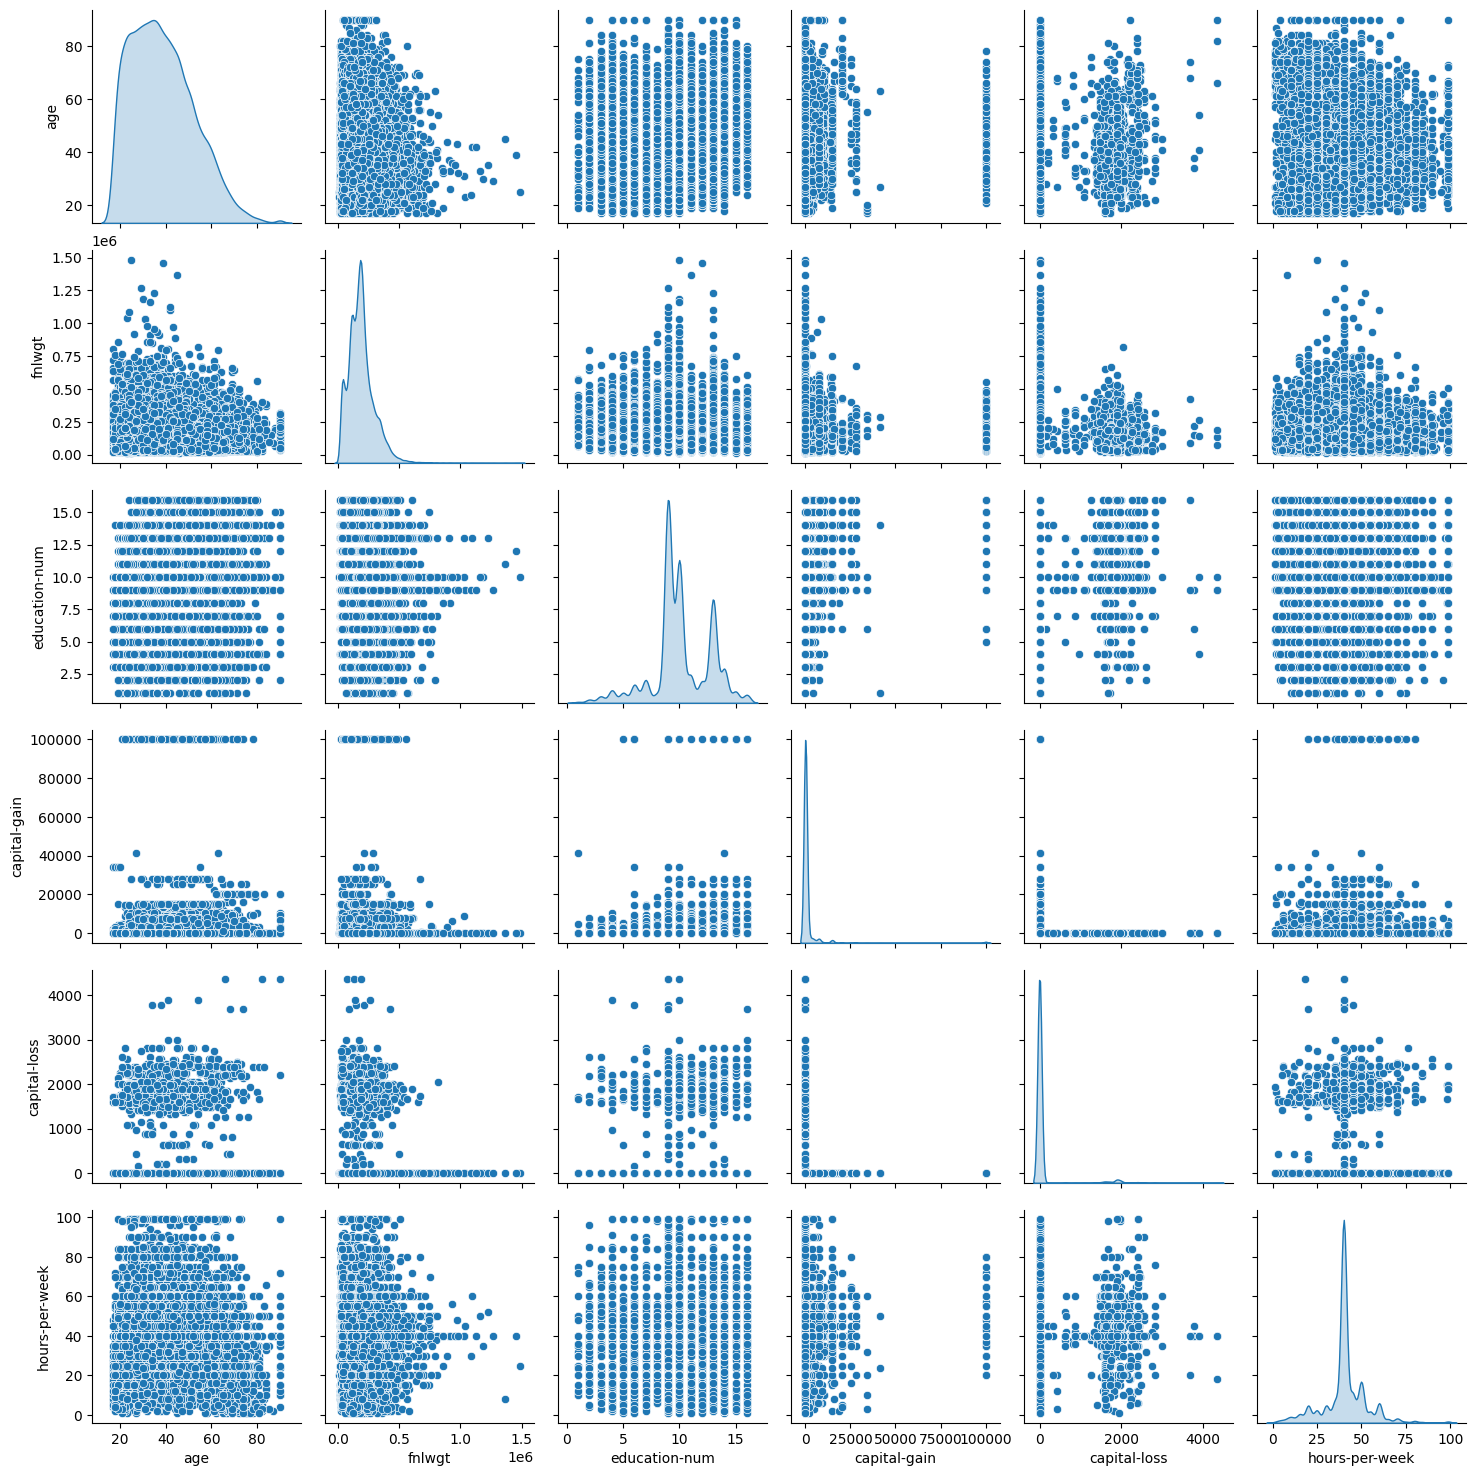

In [5]:
numeric_cols = df_adult.select_dtypes(include=['int64', 'float64']).columns.to_list()
# Create a pairplot for numeric columns
sns.pairplot(df_adult, diag_kind='kde')

<Axes: >

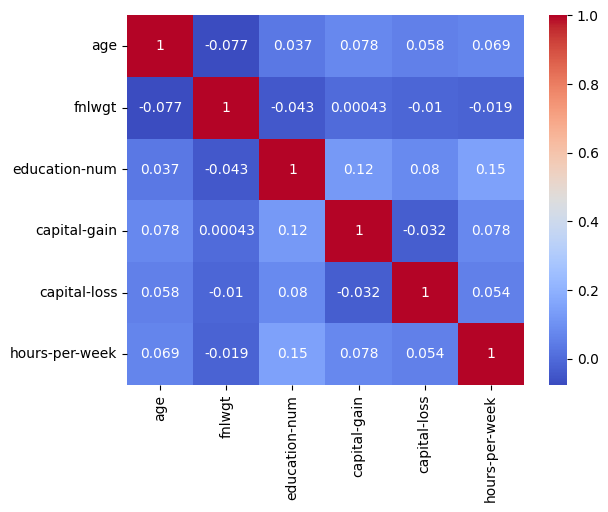

In [6]:
sns.heatmap(df_adult[numeric_cols].corr(), annot=True, cmap='coolwarm') 

In [7]:
from sklearn.model_selection import train_test_split
df_adult["income"] = df_adult["income"].apply(lambda x: 1 if x == '>50K' else 0)  # Convert income to binary
df_train, df_test = train_test_split(df_adult, test_size=0.2, random_state=42)
missing_na = ['workclass', 'occupation', 'native-country']
# Impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df_train[missing_na] = imputer.fit_transform(df_train[missing_na])
df_test[missing_na] = imputer.transform(df_test[missing_na])

X_train, X_test, y_train, y_test = df_train.drop('income', axis=1), df_test.drop('income', axis=1), df_train['income'], df_test['income']

In [8]:
X_train.rename(columns={"hours-per-week": "hours_per_week"}, inplace=True)
X_test.rename(columns={"hours-per-week": "hours_per_week"}, inplace=True)

In [9]:
y_train

5514     1
19777    1
10781    0
32240    0
9876     0
        ..
29802    0
5390     0
860      0
15795    0
23654    0
Name: income, Length: 26048, dtype: int64

In [12]:
# Fit basic logistic GLM
log = smf.glm(formula = "income ~ age + education-num + hours_per_week + C(workclass) + C(relationship) + C(sex)", data=pd.concat([X_train, y_train], axis=1), family=sm.families.Binomial(link=sm.families.links.Logit()))
log_results = log.fit()

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Make predictions on the test set
y_pred = log_results.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)
# Print classification report
print(classification_report(y_test, y_pred_binary))
# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_binary))
# Print accuracy score
print("Accuracy Score:", accuracy_score(y_test, y_pred_binary))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4942
           1       0.68      0.51      0.58      1571

    accuracy                           0.82      6513
   macro avg       0.77      0.72      0.74      6513
weighted avg       0.81      0.82      0.82      6513

Confusion Matrix:
[[4571  371]
 [ 772  799]]
Accuracy Score: 0.8245048364808844


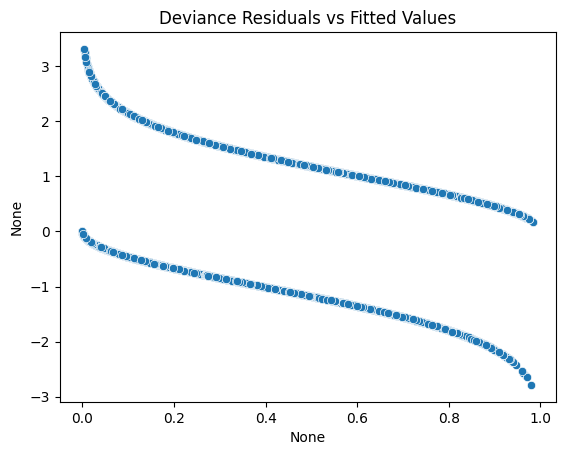

In [14]:
from scipy import stats
sns.scatterplot(x=log_results.fittedvalues, y=log_results.resid_deviance)

plt.title('Deviance Residuals vs Fitted Values')
plt.xlabel='Fitted Values'
plt.ylabel='Pearson Residuals'
plt.show()

In [17]:
# LightGBM
from lightgbm import LGBMClassifier
# Initialize LightGBM classifier
lgbm = LGBMClassifier(n_estimators=100, random_state=42)

categoric_variables = X_train.select_dtypes(include=['object']).columns.tolist()
# Set type "category" for categorical variables
for col in categoric_variables:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
# Fit the model
lgbm.fit(X_train, y_train)
# Make predictions on the test set
y_pred_lgbm = lgbm.predict(X_test)
# Print classification report for LightGBM
print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgbm))
# Print confusion matrix for LightGBM
print("LightGBM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
# Print accuracy score for LightGBM
print("LightGBM Accuracy Score:", accuracy_score(y_test, y_pred_lgbm))

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4942
           1       0.79      0.68      0.73      1571

    accuracy                           0.88      6513
   macro avg       0.85      0.81      0.83      6513
weighted avg       0.88      0.88      0.88      6513

LightGBM Confusion Matrix:
[[4662  280]
 [ 502 1069]]
LightGBM Accuracy Score: 0.8799324428066942
